In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 


In [42]:
df = pd.read_csv('screen_time_app_usage_dataset.csv')


In [43]:
# Display the first few rows of the dataset
print("\nFirst few rows of the dataset:")
print(df.head())


First few rows of the dataset:
   user_id                           date     app_name       category  \
0     1051  2024-01-01 00:00:00.000000000       Camera      Utilities   
1     1088  2024-01-01 00:43:41.673891297       Chrome      Utilities   
2     1052  2024-01-01 01:27:23.347782594      Spotify  Entertainment   
3     1028  2024-01-01 02:11:05.021673891  Google Maps      Utilities   
4     1034  2024-01-01 02:54:46.695565188    Instagram         Social   

   screen_time_min  launches  interactions  is_productive  youtube_views  \
0            24.53         2             7          False            NaN   
1            19.78         3             2          False            NaN   
2            32.03         1             6          False            NaN   
3            19.10         2             5          False            NaN   
4            25.19         1             5          False            NaN   

   youtube_likes  ...  extra_col_14  extra_col_15  extra_col_16  extra_c

In [44]:
# Display basic information about the dataset
print("\nDataset information:")
print(df.info())



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           3000 non-null   int64  
 1   date              3000 non-null   object 
 2   app_name          3000 non-null   object 
 3   category          3000 non-null   object 
 4   screen_time_min   3000 non-null   float64
 5   launches          3000 non-null   int64  
 6   interactions      3000 non-null   int64  
 7   is_productive     3000 non-null   bool   
 8   youtube_views     142 non-null    float64
 9   youtube_likes     142 non-null    float64
 10  youtube_comments  142 non-null    float64
 11  extra_col_11      3000 non-null   float64
 12  extra_col_12      3000 non-null   float64
 13  extra_col_13      3000 non-null   float64
 14  extra_col_14      3000 non-null   float64
 15  extra_col_15      3000 non-null   float64
 16  extra_col_16      30

In [45]:
print("\n===== BASIC DATASET EXPLORATION =====")
print("\nDataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())


===== BASIC DATASET EXPLORATION =====

Dataset Shape: (3000, 24)

Data Types:
user_id               int64
date                 object
app_name             object
category             object
screen_time_min     float64
launches              int64
interactions          int64
is_productive          bool
youtube_views       float64
youtube_likes       float64
youtube_comments    float64
extra_col_11        float64
extra_col_12        float64
extra_col_13        float64
extra_col_14        float64
extra_col_15        float64
extra_col_16        float64
extra_col_17        float64
extra_col_18        float64
extra_col_19        float64
extra_col_20        float64
extra_col_21        float64
extra_col_22        float64
extra_col_23        float64
dtype: object

Missing Values:
user_id                0
date                   0
app_name               0
category               0
screen_time_min        0
launches               0
interactions           0
is_productive          0
youtube_views     

In [46]:
# Drop all columns starting with 'extra_col_'
df.drop(columns=[col for col in df.columns if col.startswith('extra_col_')], inplace=True)

In [47]:
# Drop all columns starting with 'extra_col_'
df.drop(columns=['youtube_views','youtube_likes' ,'youtube_comments'], inplace=True)


In [48]:
print("\nDataset information:")
print(df.info())


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          3000 non-null   int64  
 1   date             3000 non-null   object 
 2   app_name         3000 non-null   object 
 3   category         3000 non-null   object 
 4   screen_time_min  3000 non-null   float64
 5   launches         3000 non-null   int64  
 6   interactions     3000 non-null   int64  
 7   is_productive    3000 non-null   bool   
dtypes: bool(1), float64(1), int64(3), object(3)
memory usage: 167.1+ KB
None


In [49]:
df['date'] = pd.to_datetime(df['date'])
df['day_of_week'] = df['date'].dt.day_name()
df['hour_of_day'] = df['date'].dt.hour
df['month'] = df['date'].dt.month_name()

In [50]:
print("\n===== APP CATEGORY ANALYSIS =====")
category_usage = df.groupby('category')['screen_time_min'].agg(['sum', 'mean', 'count']).reset_index()
category_usage.columns = ['Category', 'Total Screen Time (min)', 'Avg Screen Time per Session (min)', 'Number of Sessions']
print("\nScreen Time by App Category:")
print(category_usage.sort_values('Total Screen Time (min)', ascending=False))


===== APP CATEGORY ANALYSIS =====

Screen Time by App Category:
        Category  Total Screen Time (min)  Avg Screen Time per Session (min)  \
2         Social                 23753.28                          31.131429   
1   Productivity                 22283.10                          29.592430   
0  Entertainment                 21858.71                          29.984513   
3      Utilities                 21811.08                          28.888848   

   Number of Sessions  
2                 763  
1                 753  
0                 729  
3                 755  


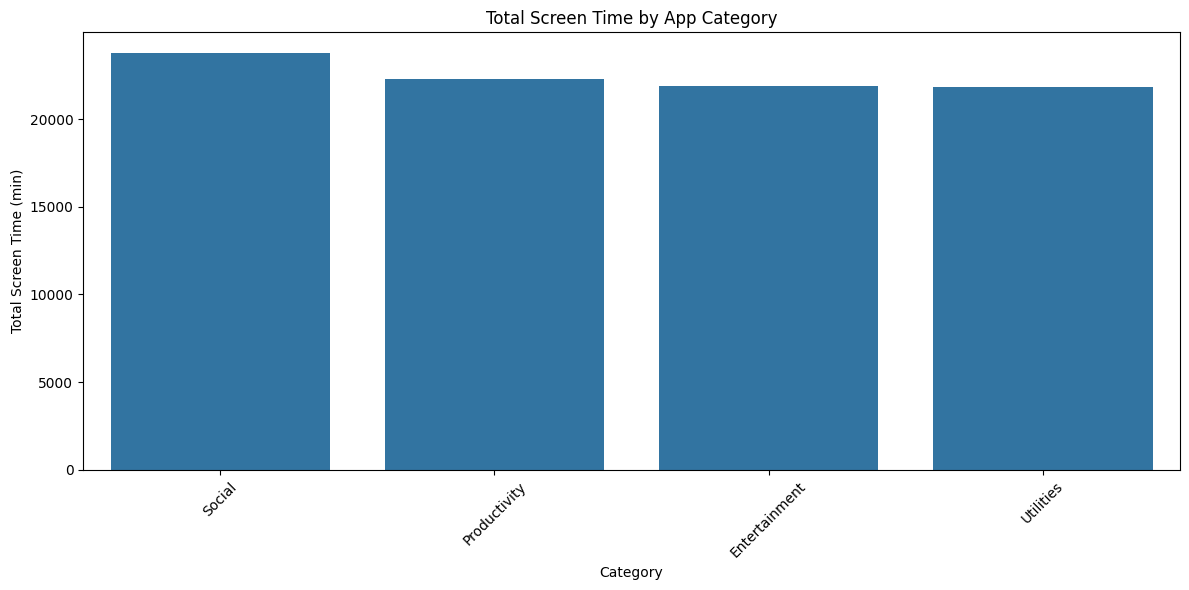

In [51]:
# Visualize category distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Total Screen Time (min)', data=category_usage.sort_values('Total Screen Time (min)', ascending=False))
plt.title('Total Screen Time by App Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('category_screen_time.png')
plt.show()

In [52]:
# 3. App-specific Analysis
print("\n===== APP-SPECIFIC ANALYSIS =====")
app_usage = df.groupby('app_name')['screen_time_min'].agg(['sum', 'mean', 'count']).reset_index()
app_usage.columns = ['App', 'Total Screen Time (min)', 'Avg Screen Time per Session (min)', 'Number of Sessions']
print("\nTop 10 Apps by Screen Time:")
print(app_usage.sort_values('Total Screen Time (min)', ascending=False).head(10))


===== APP-SPECIFIC ANALYSIS =====

Top 10 Apps by Screen Time:
                App  Total Screen Time (min)  \
13          Spotify                  5175.84   
18         WhatsApp                  5146.21   
16          Twitter                  4921.47   
12         Snapchat                  4894.68   
1            Chrome                  4876.03   
3          Facebook                  4798.49   
8   Microsoft Teams                  4743.84   
19          YouTube                  4740.60   
11            Slack                  4671.11   
6       Google Maps                  4670.36   

    Avg Screen Time per Session (min)  Number of Sessions  
13                          32.552453                 159  
18                          32.778408                 157  
16                          33.030000                 149  
12                          31.578581                 155  
1                           28.349012                 172  
3                           29.804286          

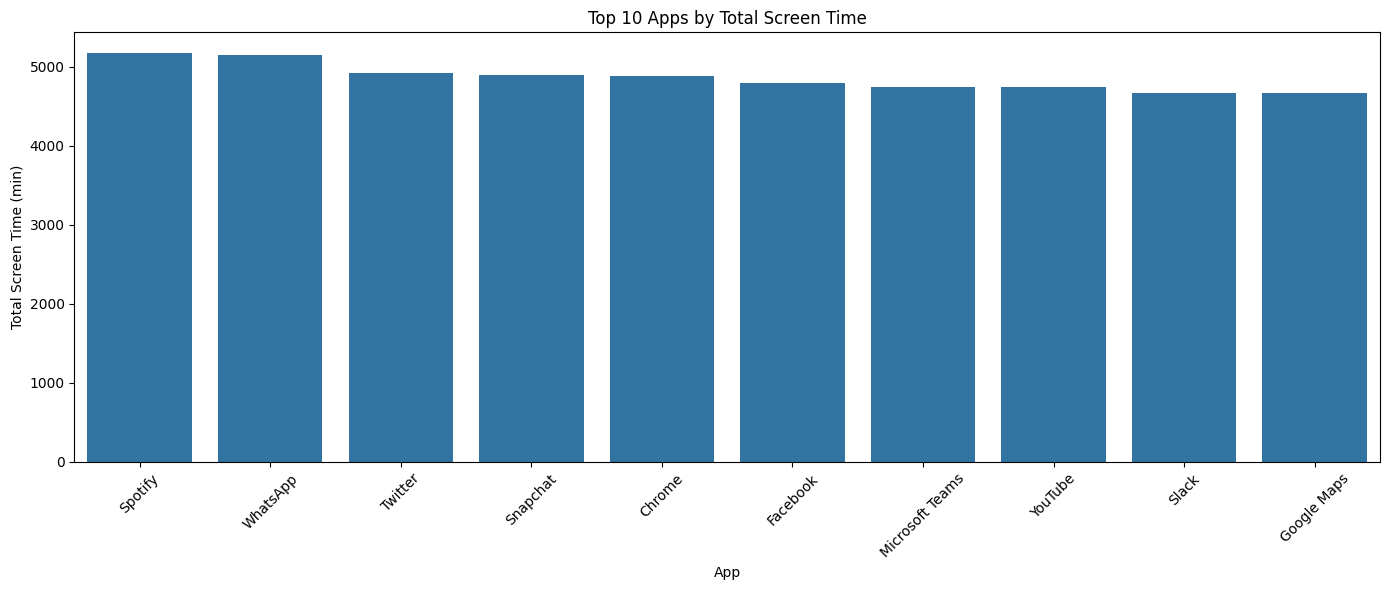

In [53]:
# Visualize top apps
plt.figure(figsize=(14, 6))
top_apps = app_usage.sort_values('Total Screen Time (min)', ascending=False).head(10)
sns.barplot(x='App', y='Total Screen Time (min)', data=top_apps)
plt.title('Top 10 Apps by Total Screen Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_apps_screen_time.png')
plt.show()

In [54]:
# 4. Productive vs. Non-productive Usage
print("\n===== PRODUCTIVE VS. NON-PRODUCTIVE USAGE =====")
productive_usage = df.groupby('is_productive')['screen_time_min'].agg(['sum', 'mean']).reset_index()
productive_usage.columns = ['Is Productive', 'Total Screen Time (min)', 'Avg Screen Time per Session (min)']
print("\nScreen Time by Productivity:")
print(productive_usage)


===== PRODUCTIVE VS. NON-PRODUCTIVE USAGE =====

Screen Time by Productivity:
   Is Productive  Total Screen Time (min)  Avg Screen Time per Session (min)
0          False                 67423.07                          30.005817
1           True                 22283.10                          29.592430


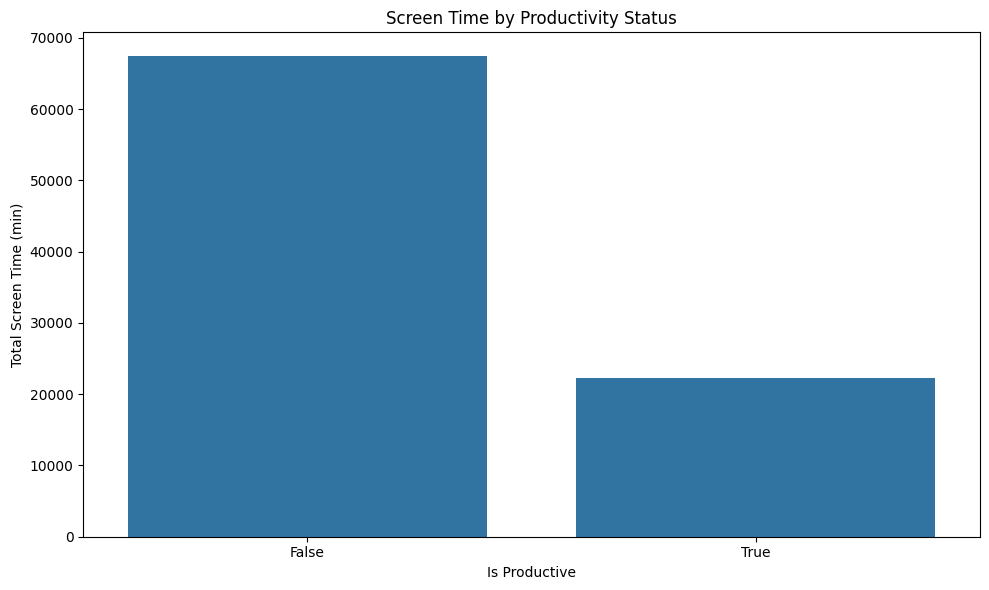

In [55]:
# Visualize productivity split
plt.figure(figsize=(10, 6))
sns.barplot(x='Is Productive', y='Total Screen Time (min)', data=productive_usage)
plt.title('Screen Time by Productivity Status')
plt.tight_layout()
plt.savefig('productive_screen_time.png')
plt.show()

In [56]:
print("\n===== TIME-BASED USAGE PATTERNS =====")



===== TIME-BASED USAGE PATTERNS =====


In [57]:
daily_usage = df.groupby('day_of_week')['screen_time_min'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("\nScreen Time by Day of Week:")
print(daily_usage)


Screen Time by Day of Week:
day_of_week
Monday       12779.40
Tuesday      12909.62
Wednesday    12752.05
Thursday     12498.16
Friday       12900.56
Saturday     13493.61
Sunday       12372.77
Name: screen_time_min, dtype: float64


In [58]:
hourly_usage = df.groupby('hour_of_day')['screen_time_min'].sum().reset_index()
print("\nScreen Time by Hour of Day (Top 5 hours):")
print(hourly_usage.sort_values('screen_time_min', ascending=False).head())


Screen Time by Hour of Day (Top 5 hours):
    hour_of_day  screen_time_min
2             2          4394.67
23           23          4255.70
1             1          4140.77
3             3          4074.59
13           13          4071.29


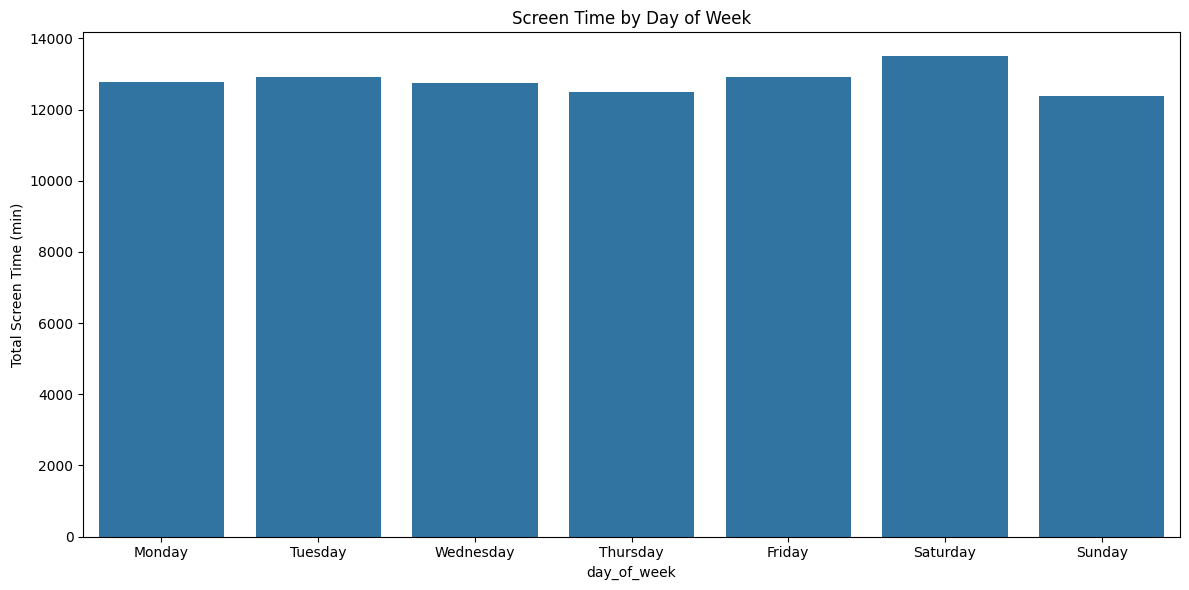

In [59]:
# Visualize daily patterns
plt.figure(figsize=(12, 6))
sns.barplot(x=daily_usage.index, y=daily_usage.values)
plt.title('Screen Time by Day of Week')
plt.ylabel('Total Screen Time (min)')
plt.tight_layout()
plt.savefig('daily_patterns.png')
plt.show()

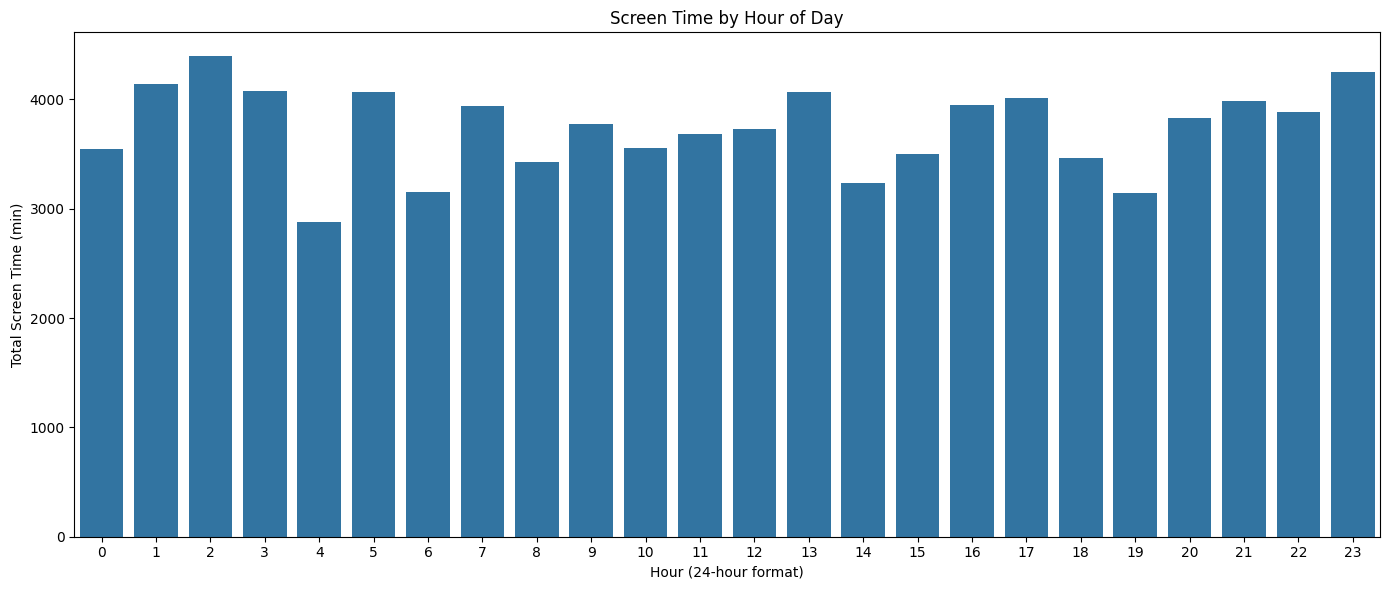

In [60]:
# Visualize hourly patterns
plt.figure(figsize=(14, 6))
sns.barplot(x='hour_of_day', y='screen_time_min', data=hourly_usage)
plt.title('Screen Time by Hour of Day')
plt.xlabel('Hour (24-hour format)')
plt.ylabel('Total Screen Time (min)')
plt.tight_layout()
plt.savefig('hourly_patterns.png')
plt.show()


In [61]:
print("\n===== USER BEHAVIOR ANALYSIS =====")
user_stats = df.groupby('user_id')['screen_time_min'].agg(['sum', 'mean', 'count']).reset_index()
user_stats.columns = ['User ID', 'Total Screen Time (min)', 'Avg Screen Time per Session (min)', 'Number of Sessions']
print("\nUser Statistics Summary:")
print(user_stats.describe())


===== USER BEHAVIOR ANALYSIS =====

User Statistics Summary:
           User ID  Total Screen Time (min)  \
count   101.000000               101.000000   
mean   1050.000000               888.179901   
std      29.300171               217.451017   
min    1000.000000               431.990000   
25%    1025.000000               731.160000   
50%    1050.000000               897.470000   
75%    1075.000000              1026.200000   
max    1100.000000              1627.730000   

       Avg Screen Time per Session (min)  Number of Sessions  
count                         101.000000          101.000000  
mean                           30.016364           29.702970  
std                             5.526997            5.548954  
min                            16.815000           17.000000  
25%                            26.427931           26.000000  
50%                            29.275000           30.000000  
75%                            32.518276           33.000000  
max       

In [62]:
# Find power users (top 10% in screen time)
power_users = user_stats.sort_values('Total Screen Time (min)', ascending=False)
power_user_threshold = np.percentile(user_stats['Total Screen Time (min)'], 90)
print(f"\nPower User Threshold (90th percentile): {power_user_threshold:.2f} minutes")
print("\nTop 5 Power Users:")
print(power_users.head())


Power User Threshold (90th percentile): 1160.47 minutes

Top 5 Power Users:
    User ID  Total Screen Time (min)  Avg Screen Time per Session (min)  \
38     1038                  1627.73                          49.325152   
80     1080                  1400.99                          32.581163   
49     1049                  1284.21                          33.795000   
1      1001                  1276.70                          35.463889   
99     1099                  1254.80                          34.855556   

    Number of Sessions  
38                  33  
80                  43  
49                  38  
1                   36  
99                  36  


In [63]:
print("\n===== CORRELATION ANALYSIS =====")
# Select numeric columns for correlation analysis
numeric_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numeric_cols].corr()
print("\nCorrelation Matrix for Key Metrics:")
print(correlation_matrix[['screen_time_min', 'launches', 'interactions']].sort_values('screen_time_min', ascending=False))


===== CORRELATION ANALYSIS =====

Correlation Matrix for Key Metrics:
                 screen_time_min  launches  interactions
screen_time_min         1.000000  0.005771      0.017420
interactions            0.017420  0.015520      1.000000
user_id                 0.006540 -0.012587      0.011059
launches                0.005771  1.000000      0.015520
hour_of_day             0.004463  0.011524      0.008711


<function matplotlib.pyplot.show(close=None, block=None)>

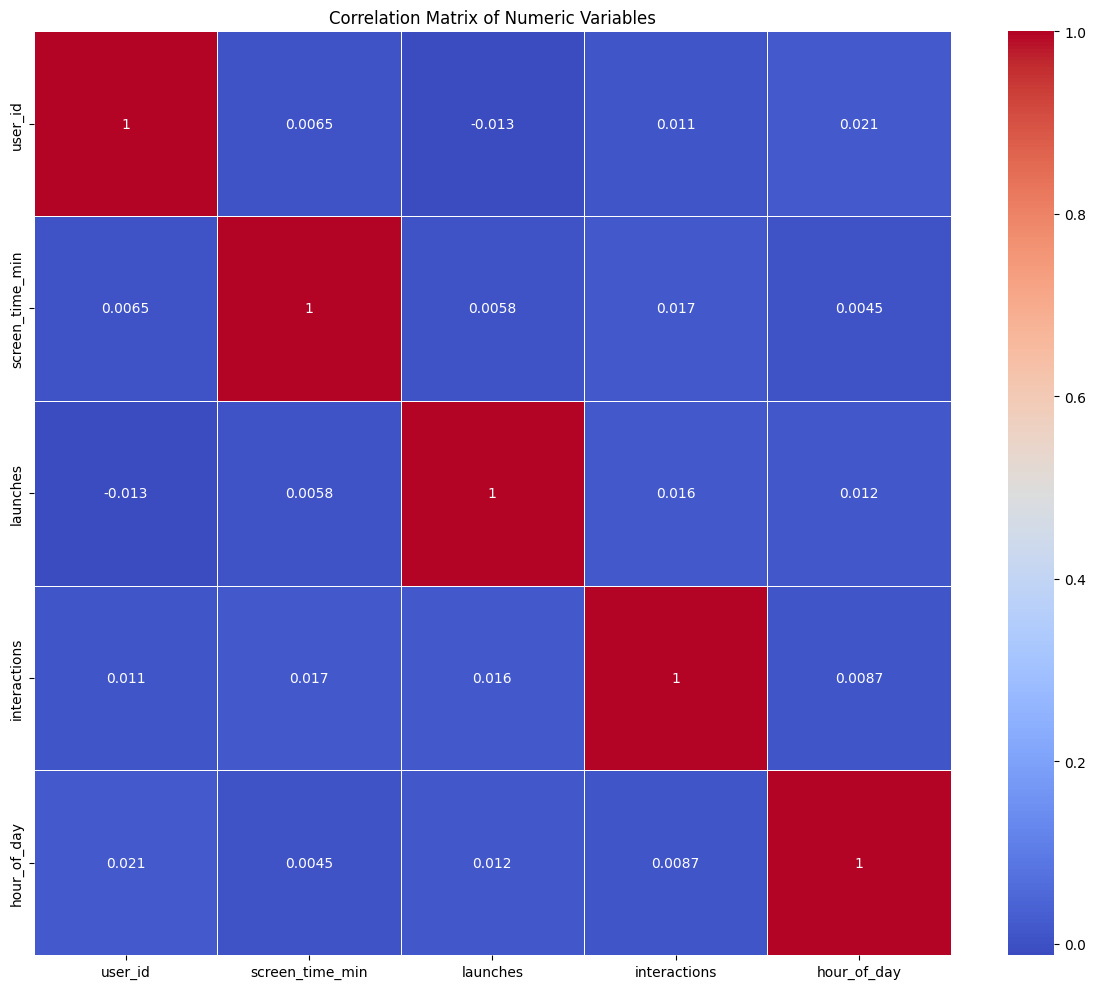

In [65]:

# Visualize correlations
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show

In [68]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go


In [69]:
 #9. Interactive Visualizations with Plotly (optional)
fig = make_subplots(rows=2, cols=2,
                   subplot_titles=('Top Apps by Screen Time', 'App Categories Distribution', 
                                  'Daily Usage Pattern', 'Hourly Usage Pattern'))

In [73]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [77]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create the subplot grid with correct types
fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "domain"}],  # Use 'domain' for pie chart
           [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("Top 8 Apps by Screen Time", "Screen Time by Category", "Daily Usage Pattern", "Hourly Usage Pattern")
)

# Top apps chart
top_apps = app_usage.sort_values('Total Screen Time (min)', ascending=False).head(8)
fig.add_trace(
    go.Bar(x=top_apps['App'], y=top_apps['Total Screen Time (min)'], name='Screen Time'),
    row=1, col=1
)

# Categories pie chart
fig.add_trace(
    go.Pie(labels=category_usage['Category'], values=category_usage['Total Screen Time (min)'], name='Categories'),
    row=1, col=2
)

# Daily usage pattern
fig.add_trace(
    go.Bar(x=daily_usage.index, y=daily_usage.values, name='Daily Pattern'),
    row=2, col=1
)

# Hourly usage pattern
fig.add_trace(
    go.Scatter(x=hourly_usage['hour_of_day'], y=hourly_usage['screen_time_min'], mode='lines+markers', name='Hourly Pattern'),
    row=2, col=2
)

# Layout and export
fig.update_layout(
    height=800,
    width=1000,
    title_text="Mobile App Usage Dashboard",
    showlegend=True
)

fig.write_html("mobile_usage_dashboard.html")
print("\nInteractive dashboard saved as 'mobile_usage_dashboard.html'")



Interactive dashboard saved as 'mobile_usage_dashboard.html'
